In [3]:
#Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

In [4]:
#Load process datset
data = np.load(r"D:\Ai-Crop-Monitoring\models\data\processed\breizhcrops_processed.npz")

X = data["X"]
y = data["y"]
field_ids = data["field_ids"]

print("Features Shape :", X.shape)
print("Labels Shape   :", y.shape)

Features Shape : (122614, 585)
Labels Shape   : (122614,)


In [5]:
#Train tet split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Samples :", X_train.shape)
print("Testing Samples  :", X_test.shape)

Training Samples : (98091, 585)
Testing Samples  : (24523, 585)


In [6]:
#Build random forest
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

In [7]:
#train model
rf.fit(X_train, y_train)

print("Model Training Completed!")

Model Training Completed!


In [8]:
#predcition
y_pred = rf.predict(X_test)

print("Prediction Completed!")

Prediction Completed!


In [9]:
#Accuracy
accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy : {accuracy:.4f}")
print(f"Accuracy : {accuracy*100:.2f}%")

Accuracy : 0.7106
Accuracy : 71.06%


In [10]:
#Classification report
report = classification_report(y_test, y_pred)

print(report)

              precision    recall  f1-score   support

           0       0.92      0.23      0.36      1196
           1       0.86      0.82      0.84      3399
           2       0.98      0.69      0.81       647
           3       0.87      0.95      0.91      6267
           5       0.00      0.00      0.00       111
           6       0.00      0.00      0.00         2
           7       0.58      0.36      0.44      5223
           8       0.58      0.80      0.67      7678

    accuracy                           0.71     24523
   macro avg       0.60      0.48      0.50     24523
weighted avg       0.72      0.71      0.69     24523



C:\Users\SUYASH\AppData\Roaming\Python\Python311\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\SUYASH\AppData\Roaming\Python\Python311\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\SUYASH\AppData\Roaming\Python\Python311\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capi

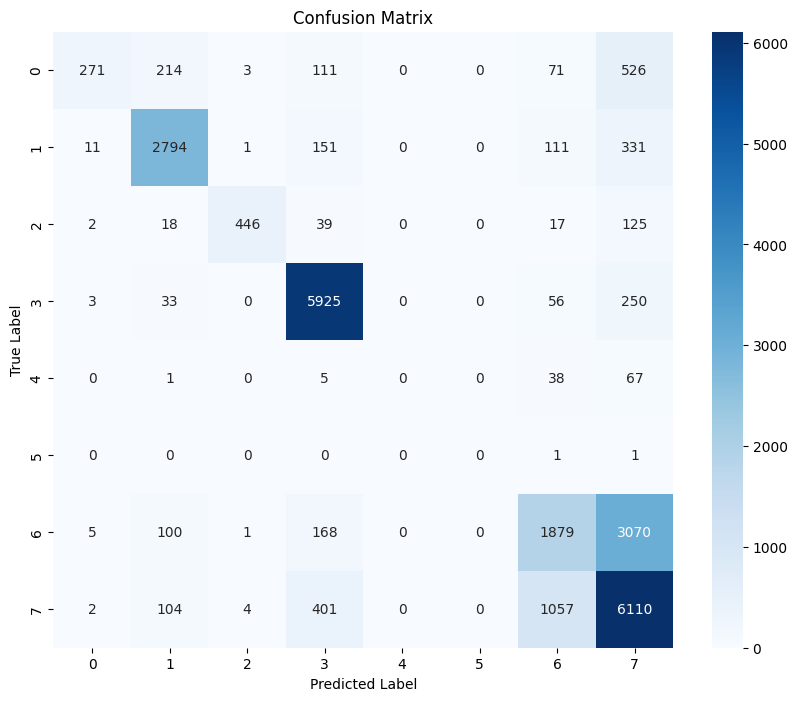

In [11]:
#Confusion matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10,8))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

In [12]:
#Feature importance
feature_importance = pd.DataFrame({
    "Feature": np.arange(X.shape[1]),
    "Importance": rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
162,162,0.012535
119,119,0.012390
123,123,0.012305
122,122,0.011756
127,127,0.011248
129,129,0.011044
118,118,0.010258
161,161,0.010171
128,128,0.010121
158,158,0.008802


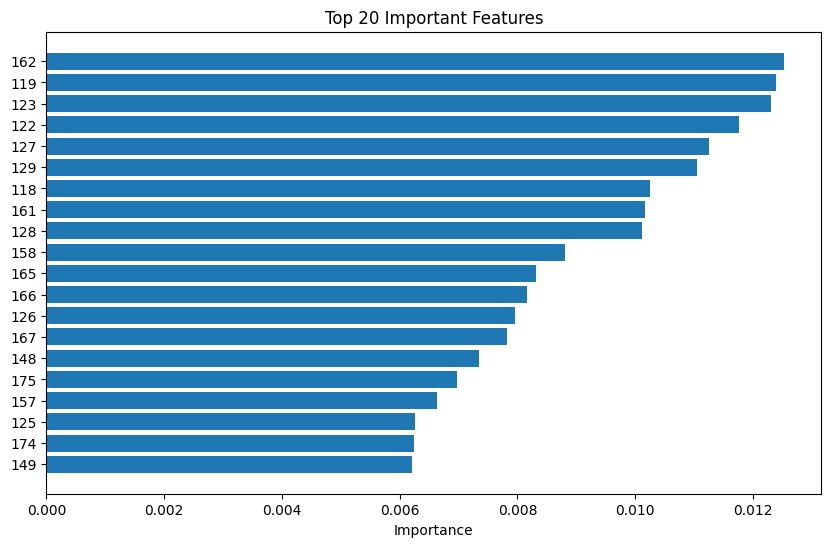

In [13]:
top20 = feature_importance.head(20)

plt.figure(figsize=(10,6))

plt.barh(
    top20["Feature"].astype(str),
    top20["Importance"]
)

plt.gca().invert_yaxis()

plt.title("Top 20 Important Features")

plt.xlabel("Importance")

plt.show()

In [14]:
print("="*40)
print("Model Summary")
print("="*40)

print(f"Algorithm : Random Forest")
print(f"Training Samples : {len(X_train)}")
print(f"Testing Samples : {len(X_test)}")
print(f"Features : {X.shape[1]}")
print(f"Classes : {len(np.unique(y))}")
print(f"Accuracy : {accuracy*100:.2f}%")

Model Summary
Algorithm : Random Forest
Training Samples : 98091
Testing Samples : 24523
Features : 585
Classes : 9
Accuracy : 71.06%


In [15]:
import joblib
import os

os.makedirs("../models", exist_ok=True)

joblib.dump(rf, "../models/random_forest_baseline.pkl")

print("✅ Model saved successfully!")

✅ Model saved successfully!


In [16]:
print("Training classes:")
print(pd.Series(y_train).value_counts().sort_index())

print("\nTesting classes:")
print(pd.Series(y_test).value_counts().sort_index())

Training classes:
0     4782
1    13594
2     2589
3    25066
4        2
5      442
6        9
7    20894
8    30713
Name: count, dtype: int64

Testing classes:
0    1196
1    3399
2     647
3    6267
5     111
6       2
7    5223
8    7678
Name: count, dtype: int64


# Hyperparameter Tuning for Random Forest Classifier

In [17]:
from sklearn.model_selection import GridSearchCV

In [18]:
param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [20, None],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2],
    "max_features": ["sqrt"]
}

In [19]:
rf = RandomForestClassifier(
    random_state=42,
    n_jobs=-1
)

In [20]:
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=3,
    scoring="accuracy",
    n_jobs=-1,
    verbose=2
)

In [21]:
grid_search.fit(X_train, y_train)
# This is the longest step. It will train:

# 16 parameter combinations
# × 3-fold cross-validation

# Total:

# 48 Random Forest models

Fitting 3 folds for each of 16 candidates, totalling 48 fits


C:\Users\SUYASH\AppData\Roaming\Python\Python311\site-packages\sklearn\model_selection\_split.py:811: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=3.
  warnings.warn(


,estimator,RandomForestC...ndom_state=42)
,param_grid,"{'max_depth': [20, None], 'max_features': ['sqrt'], 'min_samples_leaf': [1, 2], 'min_samples_split': [2, 5], ...}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,3
,verbose,2
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,200


In [22]:
print("Best Parameters:")
print(grid_search.best_params_)

Best Parameters:
{'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}


In [23]:
print("Best Cross Validation Accuracy:")
print(grid_search.best_score_)

Best Cross Validation Accuracy:
0.7036119521668655


In [24]:
best_rf = grid_search.best_estimator_

y_pred = best_rf.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print(f"Test Accuracy: {accuracy:.4f}")

Test Accuracy: 0.7119


### Conclusion for Hyperparameter Tuning

Hyperparameter tuning produced only a marginal improvement (71.06% → 71.19%). This indicates that the baseline Random Forest configuration was already close to optimal. The main limitation is not the model configuration but the dataset itself, particularly the severe class imbalance and similarity between some crop classes.

In [25]:
rf_balanced = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"
)

In [26]:
rf_balanced.fit(X_train, y_train)

,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [27]:
y_pred_balanced = rf_balanced.predict(X_test)

In [28]:
accuracy = accuracy_score(y_test, y_pred_balanced)

print(f"Accuracy: {accuracy:.4f}")

print("\nClassification Report\n")
print(classification_report(y_test, y_pred_balanced))

Accuracy: 0.7013

Classification Report

              precision    recall  f1-score   support

           0       0.95      0.24      0.39      1196
           1       0.88      0.80      0.84      3399
           2       0.98      0.71      0.82       647
           3       0.87      0.93      0.90      6267
           5       0.00      0.00      0.00       111
           6       0.00      0.00      0.00         2
           7       0.62      0.26      0.37      5223
           8       0.55      0.85      0.67      7678

    accuracy                           0.70     24523
   macro avg       0.61      0.47      0.50     24523
weighted avg       0.72      0.70      0.68     24523



C:\Users\SUYASH\AppData\Roaming\Python\Python311\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\SUYASH\AppData\Roaming\Python\Python311\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\SUYASH\AppData\Roaming\Python\Python311\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capi

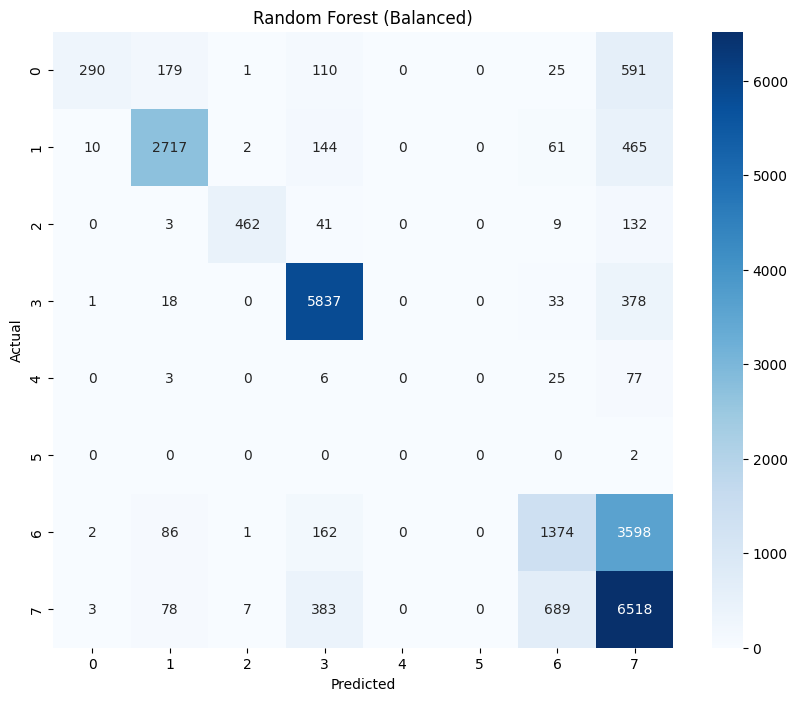

In [29]:
cm = confusion_matrix(y_test, y_pred_balanced)

plt.figure(figsize=(10,8))

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.title("Random Forest (Balanced)")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

### Conclusion for Experiment 1

Applying balanced class weights did not improve overall model performance. While recall for one majority class (Class 8) increased slightly, overall accuracy decreased and minority classes remained unrecognized. This indicates that weighting alone cannot overcome the extreme class imbalance present in the dataset.

# Project Report

## Title

**Crop Type Classification using Random Forest on Multi-Temporal Sentinel-2 Data**

---

## Objective

Build a baseline machine learning model to classify agricultural crop types using multi-temporal Sentinel-2 satellite observations and evaluate its performance.

---

## Dataset

* **Dataset:** BreizhCrops (FRH04)
* **Total Samples:** 122,614
* **Features:** 585 (45 timestamps × 13 Sentinel-2 bands)
* **Target Classes:** 9 Crop Types
* **Data Type:** float32

---

## Exploratory Data Analysis

* Verified dataset quality (no missing values or duplicates).
* Analyzed crop class distribution and identified severe class imbalance.
* Studied spectral band reflectance and temporal trends.
* Examined feature distributions, correlations, and outliers.
* Visualized PCA projection and spectral signatures of different crop classes.

---

## Models & Experiments

### 1. Baseline Random Forest

* 100 Decision Trees
* Default parameters
* **Accuracy:** **71.06%**

### 2. Hyperparameter Tuning

* Tuned `n_estimators`, `max_depth`, `min_samples_split`, `min_samples_leaf`, and `max_features` using GridSearchCV.
* Best configuration:

  * `n_estimators = 200`
  * `max_depth = None`
  * `max_features = sqrt`
  * `min_samples_split = 2`
  * `min_samples_leaf = 1`
* **Accuracy:** **71.19%**

### 3. Class Imbalance Handling

* Applied `class_weight="balanced"` in Random Forest.
* **Accuracy:** **70.13%**
* No significant improvement for extremely underrepresented classes.

---

## Evaluation Metrics

The models were evaluated using:

* Accuracy
* Precision
* Recall
* F1-Score
* Confusion Matrix
* Feature Importance

---

## Results Summary

| Model                            |   Accuracy |
| -------------------------------- | ---------: |
| Baseline Random Forest           | **71.06%** |
| Tuned Random Forest              | **71.19%** |
| Random Forest (Balanced Weights) | **70.13%** |

---

## Conclusion

The baseline Random Forest achieved strong performance (**71.06% accuracy**) on the multi-temporal satellite dataset. Hyperparameter tuning provided only a marginal improvement, while balanced class weights did not improve minority class prediction due to the dataset's extreme class imbalance. This project established a complete machine learning pipeline for satellite-based crop classification and served as a foundation for building a custom crop classification model using raw Sentinel-2 imagery in the next phase of the project.


In [1]:
from xgboost import XGBClassifier

In [11]:
model_xgb = XGBClassifier(
    objective="multi:softmax",
    num_class=9,

    n_estimators=500,
    learning_rate=0.1,

    max_depth=8,
    min_child_weight=3,

    subsample=0.8,
    colsample_bytree=0.8,

    gamma=0,

    reg_alpha=0,
    reg_lambda=1,

    tree_method="hist",

    random_state=42,
    n_jobs=-1,
    eval_metric="mlogloss"
)

In [13]:
import xgboost

print(xgboost.__version__)

3.2.0


In [20]:
model_xg = XGBClassifier(
    objective="multi:softprob",
    num_class=9,

    n_estimators=500,
    learning_rate=0.1,
    max_depth=8,

    tree_method="hist",
    device="cuda",

    random_state=42,
    eval_metric="mlogloss"
)

In [21]:
#train model
model_xg.fit(
    X_train,
    y_train,
    eval_set=[(X_test, y_test)],
    verbose=False
)

,objective,'multi:softprob'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,'cuda'
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'mlogloss'


In [22]:
#predcition
y_pred = model_xg.predict(X_test)

print("Prediction Completed!")

C:\Users\SUYASH\AppData\Roaming\Python\Python311\site-packages\xgboost\core.py:751: UserWarning: [11:32:28] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\common\error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


Prediction Completed!


In [23]:
#Accuracy
accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy : {accuracy:.4f}")
print(f"Accuracy : {accuracy*100:.2f}%")

Accuracy : 0.7828
Accuracy : 78.28%


In [24]:
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    "n_estimators": [300, 500, 700, 900],
    "max_depth": [4, 6, 8, 10],
    "learning_rate": [0.01, 0.05, 0.1, 0.2],
    "subsample": [0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.7, 0.8, 0.9, 1.0],
    "min_child_weight": [1, 3, 5],
    "gamma": [0, 0.1, 0.3, 0.5],
    "reg_alpha": [0, 0.1, 1],
    "reg_lambda": [1, 2, 5]
}

In [25]:
xgb = XGBClassifier(
    objective="multi:softprob",
    num_class=9,
    tree_method="hist",
    device="cuda",
    eval_metric="mlogloss",
    random_state=42
)

In [26]:
random_search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_dist,
    n_iter=20,          # Try 20 random combinations
    scoring="accuracy",
    cv=3,
    verbose=2,
    random_state=42,
    n_jobs=1            # Important when using GPU
)

In [27]:
random_search.fit(X_train, y_train)

Fitting 3 folds for each of 20 candidates, totalling 60 fits


C:\Users\SUYASH\AppData\Roaming\Python\Python311\site-packages\sklearn\model_selection\_split.py:811: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=3.
  warnings.warn(


[CV] END colsample_bytree=0.7, gamma=0.3, learning_rate=0.05, max_depth=4, min_child_weight=3, n_estimators=700, reg_alpha=1, reg_lambda=1, subsample=1.0; total time= 1.4min
[CV] END colsample_bytree=0.7, gamma=0.3, learning_rate=0.05, max_depth=4, min_child_weight=3, n_estimators=700, reg_alpha=1, reg_lambda=1, subsample=1.0; total time= 1.5min
[CV] END colsample_bytree=0.7, gamma=0.3, learning_rate=0.05, max_depth=4, min_child_weight=3, n_estimators=700, reg_alpha=1, reg_lambda=1, subsample=1.0; total time= 1.4min
[CV] END colsample_bytree=0.7, gamma=0, learning_rate=0.01, max_depth=6, min_child_weight=5, n_estimators=900, reg_alpha=1, reg_lambda=5, subsample=0.7; total time= 4.0min
[CV] END colsample_bytree=0.7, gamma=0, learning_rate=0.01, max_depth=6, min_child_weight=5, n_estimators=900, reg_alpha=1, reg_lambda=5, subsample=0.7; total time= 3.9min
[CV] END colsample_bytree=0.7, gamma=0, learning_rate=0.01, max_depth=6, min_child_weight=5, n_estimators=900, reg_alpha=1, reg_lambda

,estimator,"XGBClassifier..._class=9, ...)"
,param_distributions,"{'colsample_bytree': [0.7, 0.8, ...], 'gamma': [0, 0.1, ...], 'learning_rate': [0.01, 0.05, ...], 'max_depth': [4, 6, ...], ...}"
,n_iter,20
,scoring,'accuracy'
,n_jobs,1
,refit,True
,cv,3
,verbose,2
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [28]:
#Accuracy
accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy : {accuracy:.4f}")
print(f"Accuracy : {accuracy*100:.2f}%")

Accuracy : 0.7828
Accuracy : 78.28%


In [30]:
import joblib
import os
os.makedirs("../models", exist_ok=True)

joblib.dump(random_search, "../models/xgboost_random_search.pkl")

print("✅ Model saved successfully!")

✅ Model saved successfully!
